Our goal is to train a ML classifier to predict convection onset. We will be using environmental variables from ERA5 for our input matrix and precipitation flags from TOOCAN for our target vector.

**Disclaimer**: The following code was written with the help of Gemini.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import warnings
import glob
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score


In [2]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
era5_dir = '/glade/work/addisus/GPM_TOOCAN_data/era5_select'
toocan_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan/'
toocan_temp_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_TbExpand'
toocan_precip_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_CnvStrNorainFlag'
toocan_stage_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_lifestage'

# Create Dataframes

In [4]:
def get_common_dates():
    date_sets = []
    for directory in [era5_dir, toocan_dir, toocan_temp_dir, toocan_precip_dir]:
        dates = {
            name[:8]
            for name in os.listdir(directory)
            if len(name) >= 8 and name[:8].isdigit()
        }
        date_sets.append(dates)

    common_dates = sorted(set.intersection(*date_sets))
    return common_dates


common_dates = get_common_dates()
sample_week = common_dates[:7]  # first 7 common dates

In [5]:
def find_sample(date, dir):
    sample = ""
    for d in os.listdir(dir):
        if date in d:
            sample = d
            break
    return sample

def find_paths(date):
    sample_era5 = find_sample(date, era5_dir)
    sample_toocan = find_sample(date, toocan_dir)
    sample_toocan_temp = find_sample(date, toocan_temp_dir)
    era5_path = os.path.join(era5_dir, sample_era5)
    toocan_path = os.path.join(toocan_dir, sample_toocan)
    toocan_temp_path = os.path.join(toocan_temp_dir, sample_toocan_temp)
    return era5_path, toocan_path, toocan_temp_path

In [7]:
def select_era5_nc2(ds_era5, t, s, target_offset_hr=-6.0):
    dt = ds_era5['deltatime'].values[:, t].astype(float)
    dt = np.where(dt <= -9000, np.nan, dt)

    def ok(arr):                      # arr shape (nc2, nlvl) -> (nc2,) bool
        a = arr.astype(float)
        return np.any(~((a <= -9000) | np.isnan(a)), axis=1)

    cape0 = ds_era5['CAPE'].values[:, 0, t, s].astype(float)
    has_cape = ~((cape0 <= -9000) | np.isnan(cape0))

    has_prof = (ok(ds_era5['uprof'].values[:, t, s, :])
              | ok(ds_era5['vprof'].values[:, t, s, :])
              | ok(ds_era5['tprof'].values[:, 0, t, s, :])
              | ok(ds_era5['qprof'].values[:, 0, t, s, :]))

    dt = np.where(has_cape | has_prof, dt, np.nan)
    if np.all(np.isnan(dt)):
        return None, np.nan
    j = int(np.nanargmin(np.abs(dt - target_offset_hr)))
    return j, dt[j]

In [8]:
def build_ml_matrix(era5_path, toocan_path, date_string, target_offset_hr=-6.0):
    with xr.open_dataset(era5_path) as ds_era5, \
         xr.open_dataset(toocan_path) as ds_toocan:

        matrix_rows = []
        nt = ds_toocan.sizes['nt']
        nsysmax = ds_toocan.sizes['nsysmax']

        for t in range(nt):
            for s in range(nsysmax):
                dcs_id = ds_toocan['DCS_number'].values[t, s]
                if np.isnan(dcs_id) or dcs_id <= 0:
                    continue

                # --- Target Label ---
                grids = ds_toocan['ngrids'].values[:, t, s].astype(float)
                grids = np.where(grids <= -9000, np.nan, grids)
                conv_grids = grids[0]
                nconv_grids = grids[1]
                gpm_total = grids[3]
                conv_fraction = float(np.clip(conv_grids / gpm_total, 0.0, 1.0))

                if np.all(np.isnan(conv_grids)) or np.all(np.isnan(gpm_total)) or gpm_total <= 0:
                    continue
                if conv_grids > 0:
                    target_y = 1
                elif nconv_grids == 0:
                    target_y = 0
                else:
                    continue  # stratiform-only -> excluded, explicitly

                # --- pick ERA5 match closest to system timestamp ---
                nc2_idx, delta_used = select_era5_nc2(ds_era5, t, s, target_offset_hr)
                if nc2_idx is None:
                    continue

                # --- CAPE: documented slots, per-element masking ---
                n_era5 = ds_era5['ngrids'].values[0, t, s]
                n_era5 = np.nan if (np.isnan(n_era5) or n_era5 <= -9000) else float(n_era5)

                cape_raw = np.where(ds_era5['CAPE'].values[nc2_idx, :, t, s].astype(float) <= -9000,
                                    np.nan, ds_era5['CAPE'].values[nc2_idx, :, t, s].astype(float))

                if not np.isnan(n_era5) and n_era5 >= 4:
                    cape_mean, cape_25, cape_50, cape_75 = cape_raw[0], cape_raw[1], cape_raw[2], cape_raw[3]
                    tprof = ds_era5['tprof'].values[nc2_idx, 0, t, s, :].astype(float)
                    qprof = ds_era5['qprof'].values[nc2_idx, 0, t, s, :].astype(float)
                elif not np.isnan(n_era5) and n_era5 > 0:
                    k = min(int(n_era5), cape_raw.size)
                    cape_mean = np.nanmean(cape_raw[:k]) if not np.all(np.isnan(cape_raw[:k])) else np.nan
                    cape_25 = cape_50 = cape_75 = np.nan
                    tprof = np.nanmean(np.where(ds_era5['tprof'].values[nc2_idx, :k, t, s, :] <= -9000,
                                                np.nan, ds_era5['tprof'].values[nc2_idx, :k, t, s, :]), axis=0)
                    qprof = np.nanmean(np.where(ds_era5['qprof'].values[nc2_idx, :k, t, s, :] <= -9000,
                                                np.nan, ds_era5['qprof'].values[nc2_idx, :k, t, s, :]), axis=0)
                else:
                    continue

                # --- profiles ---
                uprof = ds_era5['uprof'].values[nc2_idx, t, s, :].astype(float)
                vprof = ds_era5['vprof'].values[nc2_idx, t, s, :].astype(float)
                uprof = np.where(uprof <= -9000, np.nan, uprof)
                vprof = np.where(vprof <= -9000, np.nan, vprof)
                tprof = np.where(tprof <= -9000, np.nan, tprof)
                qprof = np.where(qprof <= -9000, np.nan, qprof)

                # --- Base Data Row ---
                row = {
                    'Date': date_string,
                    'Time_Step': t,
                    'delta_used' : delta_used,
                    'DCS_ID': dcs_id,
                    'Target_Convection_On': target_y,
                    'Target_Conv_Fraction': conv_fraction,
                    'CAPE_mean': cape_mean,
                    'CAPE_25th': cape_25,
                    'CAPE_50th': cape_50,
                    'CAPE_75th': cape_75,
                }

                # --- Near-surface levels 0-2: pressure varies by row (terrain-following),
                # so raw lvl_0/1/2 columns don't mean the same pressure across rows.
                # Replace with engineered features that are well-defined regardless
                # of the exact pressure: near-surface mean and 0-2 "shear"/gradient.
                SFC = slice(0, 3)  # levels 0, 1, 2
                for name, prof in [('uprof', uprof), ('vprof', vprof),
                                   ('tprof', tprof), ('qprof', qprof)]:
                    sfc_vals = prof[SFC]
                    row[f'ERA5_{name}_sfc_mean'] = np.nanmean(sfc_vals) if np.any(np.isfinite(sfc_vals)) else np.nan
                    row[f'ERA5_{name}_sfc_grad'] = (
                        sfc_vals[2] - sfc_vals[0]
                        if np.isfinite(sfc_vals[0]) and np.isfinite(sfc_vals[2]) else np.nan
                    )

                # --- Levels 3-14: fixed standard pressures (850...50 hPa), safe as raw columns ---
                for name, prof in [('uprof', uprof), ('vprof', vprof),
                                   ('tprof', tprof), ('qprof', qprof)]:
                    for lvl in range(3, len(prof)):
                        row[f'ERA5_{name}_lvl_{lvl}'] = prof[lvl]

                matrix_rows.append(row)

    df = pd.DataFrame(matrix_rows)

    feat = [c for c in df.columns
            if c.startswith(('ERA5_uprof', 'ERA5_vprof', 'ERA5_tprof', 'ERA5_qprof', 'CAPE_'))]
    df[feat] = df[feat].mask(df[feat] <= -9000, np.nan)
    return df

In [9]:
os.makedirs('data', exist_ok=True)
for date in common_dates:
    if os.path.exists(f'data/{date}_df.parquet'):
        print(f"Skipping {date} as it already exists.")
        continue
    era5_path, toocan_path, _ = find_paths(date)
    df = build_ml_matrix(era5_path, toocan_path, date)
    if df.empty:
        print(f"no rows for {date}, skipping")
        continue
    df.to_parquet(f'data/{date}_df.parquet', engine='pyarrow', index=False)
    print(f"Saved {date}_df.parquet")

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/apps/opt/miniforge/envs/npl-2026a/share/proj failed


Saved 20140319_df.parquet
Saved 20140320_df.parquet
Saved 20140321_df.parquet
Saved 20140322_df.parquet
Saved 20140323_df.parquet
Saved 20140324_df.parquet
Saved 20140325_df.parquet
Saved 20140326_df.parquet
Saved 20140327_df.parquet
Saved 20140328_df.parquet
Saved 20140329_df.parquet
Saved 20140330_df.parquet
Saved 20140331_df.parquet
Saved 20140401_df.parquet
Saved 20140402_df.parquet
Saved 20140403_df.parquet
Saved 20140404_df.parquet
Saved 20140405_df.parquet
Saved 20140406_df.parquet
Saved 20140407_df.parquet
Saved 20140408_df.parquet
Saved 20140409_df.parquet
Saved 20140410_df.parquet
Saved 20140411_df.parquet
Saved 20140412_df.parquet
Saved 20140413_df.parquet
Saved 20140414_df.parquet
Saved 20140415_df.parquet
Saved 20140416_df.parquet
Saved 20140417_df.parquet
Saved 20140418_df.parquet
Saved 20140419_df.parquet
Saved 20140420_df.parquet
Saved 20140421_df.parquet
Saved 20140422_df.parquet
Saved 20140423_df.parquet
Saved 20140424_df.parquet
Saved 20140425_df.parquet
Saved 201404

# Read Dataframes From Files

In [9]:
parquet_files = glob.glob('data/*_df.parquet') # Adjust path as needed

df_list = []

for file_path in parquet_files:
    df_list.append(pd.read_parquet(file_path))

df_master = pd.concat(df_list, ignore_index=True)

# Experiment 1
Target defined simply as 0/1 convective vs no rain. No other conditions enforced.

## Prepare Dataframes for Training

In [ ]:
# 1. Define columns that are strictly for metadata or targets
# These should NOT be part of your X (features)
metadata_cols = ['Time_Step', 'DCS_ID', 'Date', 'delta_used']
target_col   = ['Target_Convection_On', 'Target_Conv_Fraction']   # BOTH
cols_to_drop  = [c for c in metadata_cols + target_col if c in df_master.columns]

# 3. Create the Feature Matrix (X)
# We drop the metadata and target columns to keep only the environmental/physical features
X = df_master.drop(columns=cols_to_drop)

# 4. Create the Target Vector (y)
y = df_master[target_col[0]]


# 5. Quick validation of shapes
print(f"Feature Matrix (X) shape: {X.shape}")
print(f"Target Vector (y) shape: {y.shape}")
print(f"Class breakdown:\n{y.value_counts()}")


# Optional: Verify no missing columns were dropped if they were expected
if len(cols_to_drop) < len(metadata_cols) + len(target_col):
    print("Warning: Some metadata or target columns were not found in df_master.")

Feature Matrix (X) shape: (125179, 60)
Target Vector (y) shape: (125179,)


In [11]:
# 1. Define your groupings
# Use DCS_ID directly! TOOCAN IDs are already globally unique.
groups = df_master['DCS_ID']

# 2. Split the master dataset
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# 3. PRE-FILTER: Drop columns that are 100% NaN in the training set
# This prevents the "Shape Mismatch" error when the Imputer drops empty columns silently.
cols_to_keep = X_train.columns[X_train.notna().any()].tolist()
X_train = X_train[cols_to_keep]
X_test = X_test[cols_to_keep] # Apply exact same filter to test set so shapes match

# 4. Impute Missing Values
imputer = SimpleImputer(strategy='mean')
# Use get_feature_names_out() to guarantee column names perfectly align with the imputer's output array
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=imputer.get_feature_names_out())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out())

# 5. Normalize / Standardize
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

## Random Forest

### with `class_weight = balanced`

In [12]:
# Initialize the model
# class_weight='balanced' helps counteract the imbalance between 0s (no convection) and 1s (convection)
model = RandomForestClassifier(n_estimators=100, class_weight= "balanced", random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

In [13]:
# --- EVALUATION ---
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
# Top-Left: True Negatives (Correctly predicted clear sky)
# Bottom-Right: True Positives (Correctly predicted convection!)
# Bottom-Left: False Negatives (Missed the storm - minimize this!)
# Top-Right: False Positives (False alarm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 1296  1291]
 [  442 22014]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.50      0.60      2587
           1       0.94      0.98      0.96     22456

    accuracy                           0.93     25043
   macro avg       0.85      0.74      0.78     25043
weighted avg       0.92      0.93      0.92     25043



Average Precision Score: 0.9873


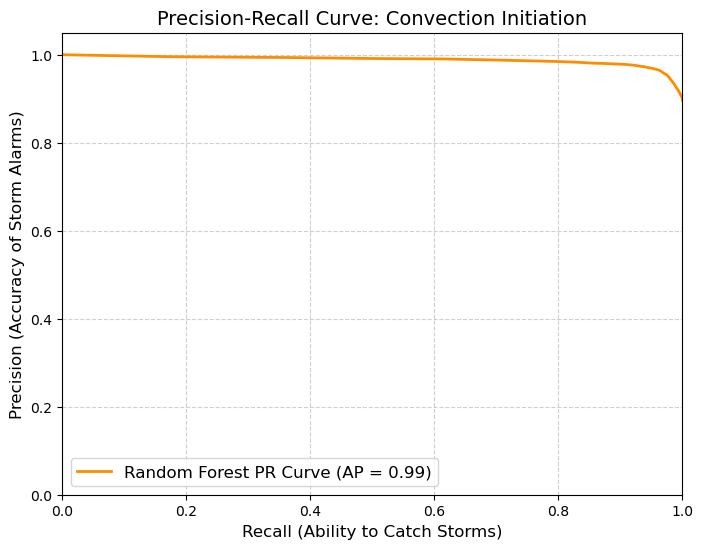

In [14]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

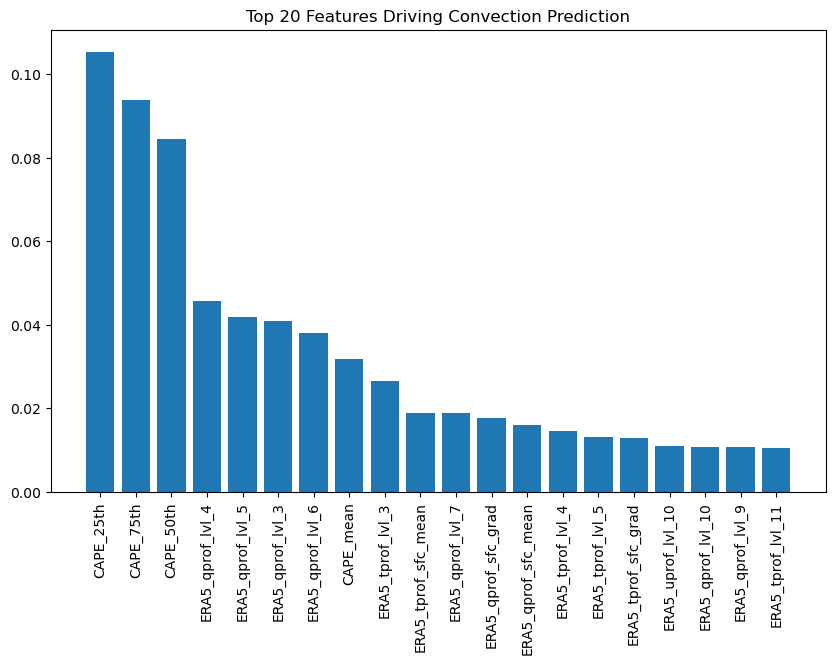

In [15]:
import matplotlib.pyplot as plt

# Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

# Plot the top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Convection Prediction")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.show()

### without `class_weight = balanced`

In [16]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

In [17]:
# --- EVALUATION ---
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
# Top-Left: True Negatives (Correctly predicted clear sky)
# Bottom-Right: True Positives (Correctly predicted convection!)
# Bottom-Left: False Negatives (Missed the storm - minimize this!)
# Top-Right: False Positives (False alarm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 1554  1033]
 [  551 21905]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.74      0.60      0.66      2587
           1       0.95      0.98      0.97     22456

    accuracy                           0.94     25043
   macro avg       0.85      0.79      0.81     25043
weighted avg       0.93      0.94      0.93     25043



Average Precision Score: 0.9869


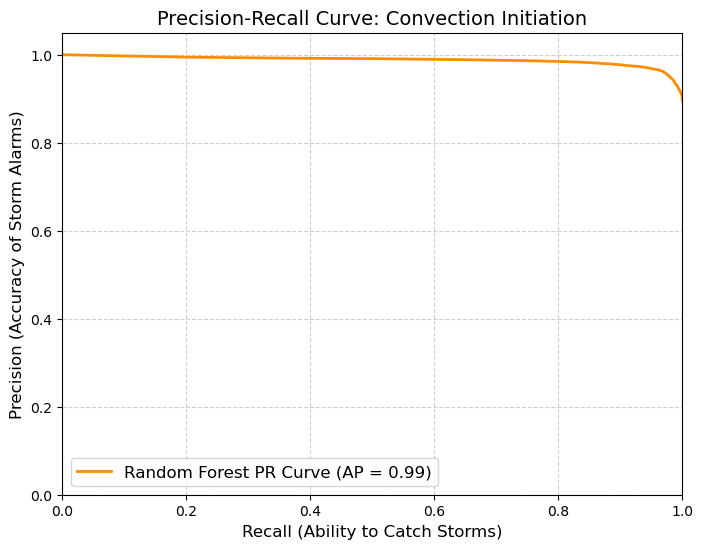

In [18]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

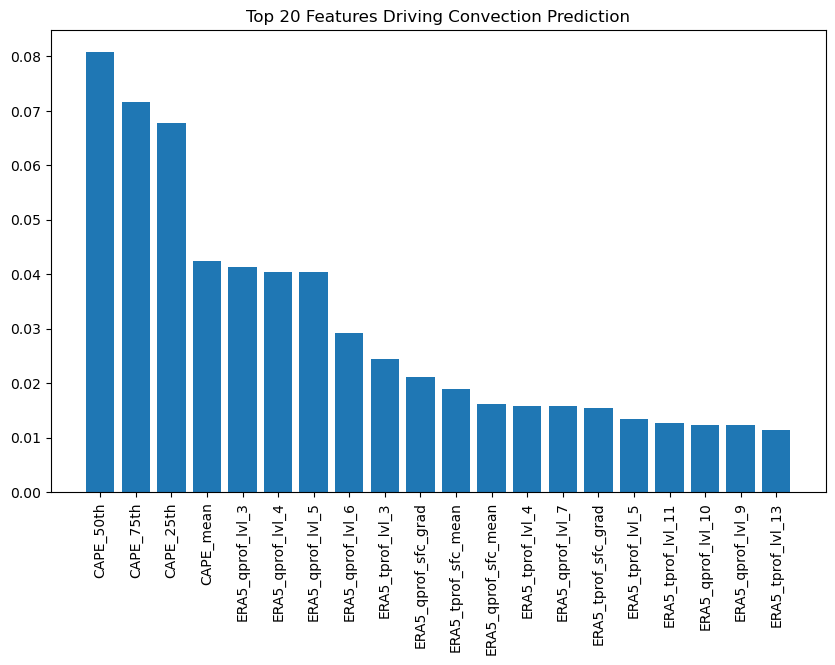

In [19]:
# Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

# Plot the top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Convection Prediction")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.show()

## Logistic Regression

### with `class_weight = balanced`

In [20]:
# 1. Initialize the model
# max_iter=1000 ensures the math solver has enough time to converge on complex climate data
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Train the model (Using SCALED data)
lr_model.fit(X_train_scaled, y_train)

# 3. Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# --- 4. EVALUATION ---
print("--- Logistic Regression Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_lr))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Confusion Matrix ---
[[ 1730   857]
 [ 3799 18657]]

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.31      0.67      0.43      2587
           1       0.96      0.83      0.89     22456

    accuracy                           0.81     25043
   macro avg       0.63      0.75      0.66     25043
weighted avg       0.89      0.81      0.84     25043



Average Precision Score: 0.9572


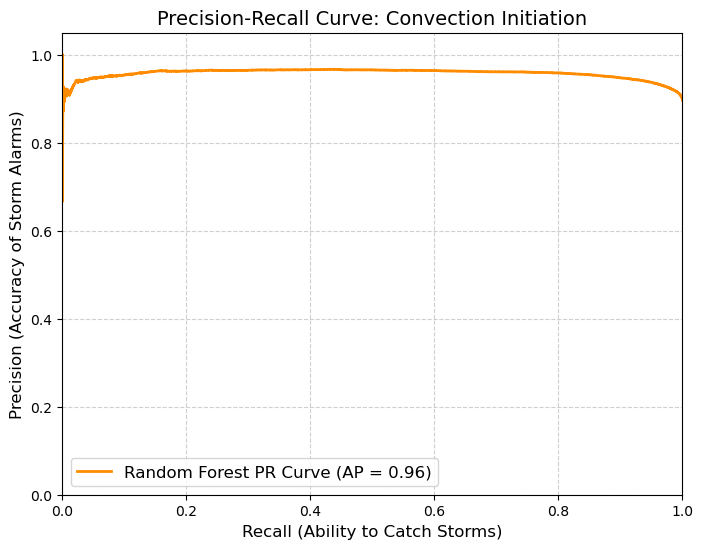

In [21]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

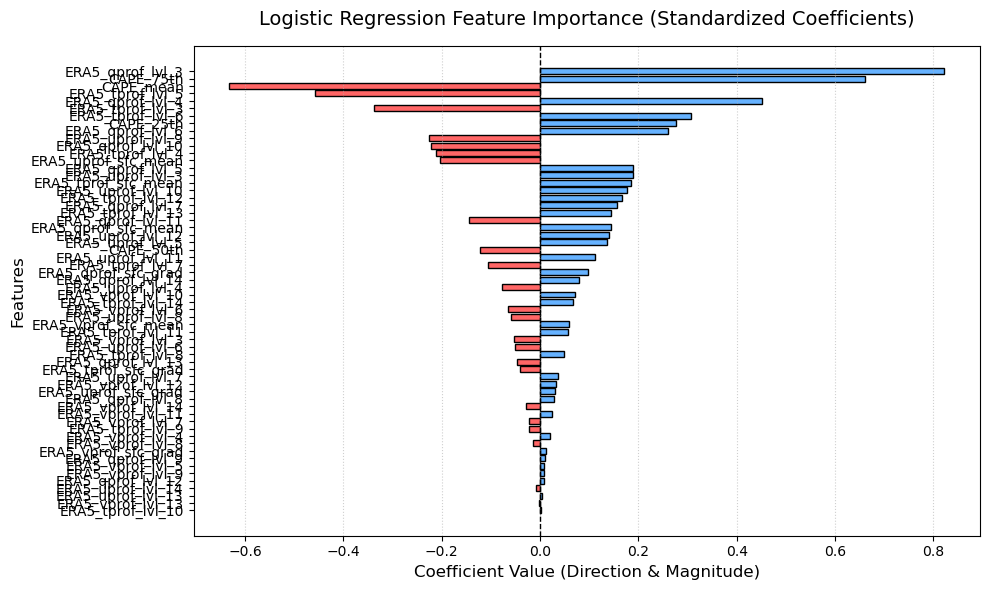

In [22]:
coefficients = lr_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values(by='AbsCoefficient', ascending=True) # Ascending for horizontal bar plot symmetry

# 6. Plotting
plt.figure(figsize=(10, 6))
colors = ['#ff6666' if c < 0 else '#66b2ff' for c in importance_df['Coefficient']]

plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.title('Logistic Regression Feature Importance (Standardized Coefficients)', fontsize=14, pad=15)
plt.xlabel('Coefficient Value (Direction & Magnitude)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### without `class_weight` = balanced

# Experiment 2
Define target y using both the rain flag data and the ratio of convective grids to total grids.

## Prepare Dataframes for Training

In [23]:
# 1. Define columns that are strictly for metadata or targets
# These should NOT be part of your X (features)
metadata_cols = ['Time_Step', 'DCS_ID', 'Date', 'delta_used']
target_col   = ['Target_Convection_On', 'Target_Conv_Fraction']   # BOTH
cols_to_drop  = [c for c in metadata_cols + target_col if c in df_master.columns]

# 3. Create the Feature Matrix (X)
# We drop the metadata and target columns to keep only the environmental/physical features
X = df_master.drop(columns=cols_to_drop)

# 4. Create the Target Vector (y)
conv_col = target_col[0]
ratio_col = target_col[1]  # Replace with your actual ratio column name

convection_mask = (df_master[conv_col].fillna(0) == 1) & (df_master[ratio_col].fillna(0) > 0.05)

y = convection_mask.astype(int)

# 5. Quick validation of shapes
print(f"Feature Matrix (X) shape: {X.shape}")
print(f"Target Vector (y) shape: {y.shape}")
print(f"Class breakdown:\n{y.value_counts()}")

# Optional: Verify no missing columns were dropped if they were expected
if len(cols_to_drop) < len(metadata_cols) + len(target_col):
    print("Warning: Some metadata or target columns were not found in df_master.")

Feature Matrix (X) shape: (125179, 60)
Target Vector (y) shape: (125179,)
Class breakdown:
1    75365
0    49814
Name: count, dtype: int64


In [24]:
# 1. Define your groupings
# Use DCS_ID directly! TOOCAN IDs are already globally unique.
groups = df_master['DCS_ID']

# 2. Split the master dataset
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# 3. PRE-FILTER: Drop columns that are 100% NaN in the training set
# This prevents the "Shape Mismatch" error when the Imputer drops empty columns silently.
cols_to_keep = X_train.columns[X_train.notna().any()].tolist()
X_train = X_train[cols_to_keep]
X_test = X_test[cols_to_keep] # Apply exact same filter to test set so shapes match

# 4. Impute Missing Values
imputer = SimpleImputer(strategy='mean')
# Use get_feature_names_out() to guarantee column names perfectly align with the imputer's output array
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=imputer.get_feature_names_out())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out())

# 5. Normalize / Standardize
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

## Random Forest

### with `class_weight = balanced`

In [25]:
# Initialize the model
# class_weight='balanced' helps counteract the imbalance between 0s (no convection) and 1s (convection)
model = RandomForestClassifier(n_estimators=100, class_weight= "balanced", random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

In [26]:
# --- EVALUATION ---
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
# Top-Left: True Negatives (Correctly predicted clear sky)
# Bottom-Right: True Positives (Correctly predicted convection!)
# Bottom-Left: False Negatives (Missed the storm - minimize this!)
# Top-Right: False Positives (False alarm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 4441  5575]
 [ 1632 13395]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.44      0.55     10016
           1       0.71      0.89      0.79     15027

    accuracy                           0.71     25043
   macro avg       0.72      0.67      0.67     25043
weighted avg       0.72      0.71      0.69     25043



Average Precision Score: 0.7952


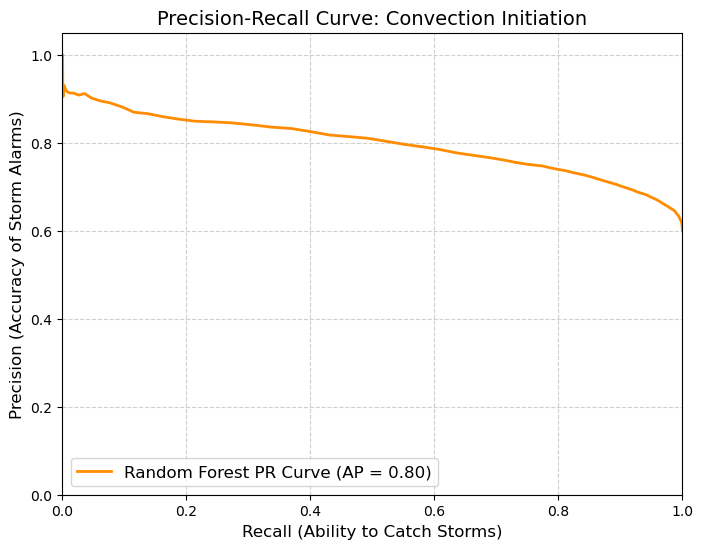

In [27]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

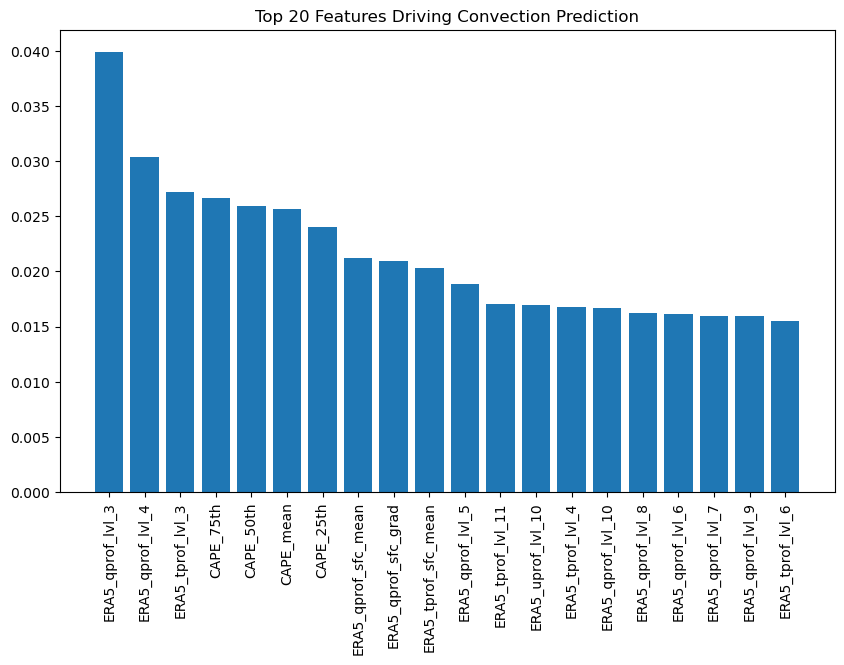

In [28]:
# Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

# Plot the top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Convection Prediction")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.show()

### without `class_weight = balanced`

In [29]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

In [30]:
# --- EVALUATION ---
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
# Top-Left: True Negatives (Correctly predicted clear sky)
# Bottom-Right: True Positives (Correctly predicted convection!)
# Bottom-Left: False Negatives (Missed the storm - minimize this!)
# Top-Right: False Positives (False alarm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 4612  5404]
 [ 1784 13243]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.46      0.56     10016
           1       0.71      0.88      0.79     15027

    accuracy                           0.71     25043
   macro avg       0.72      0.67      0.67     25043
weighted avg       0.71      0.71      0.70     25043



Average Precision Score: 0.7924


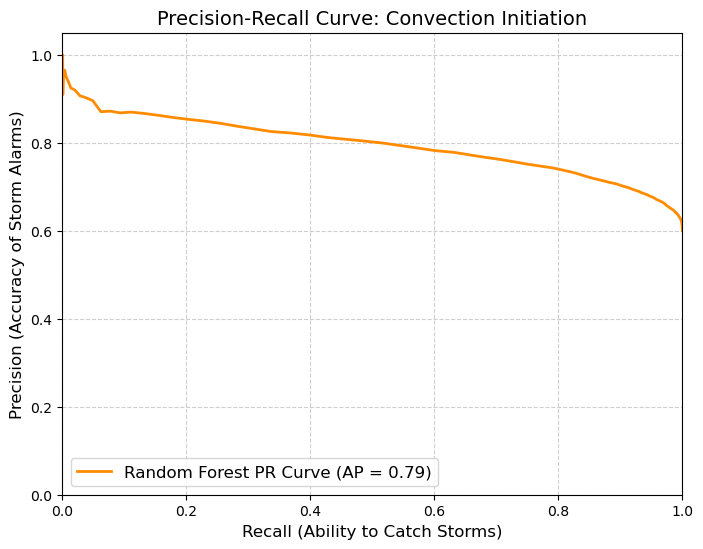

In [31]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

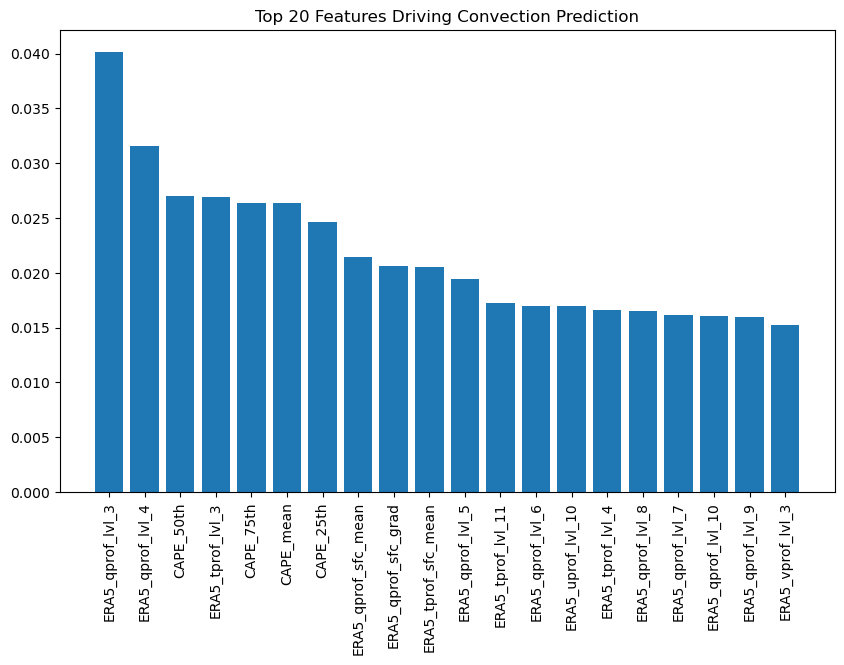

In [32]:
# Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X_train_scaled.columns
indices = np.argsort(importances)[::-1]

# Plot the top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Convection Prediction")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.show()

## Logistic Regression

### with `class_weight = balanced`

In [33]:
# 1. Initialize the model
# max_iter=1000 ensures the math solver has enough time to converge on complex climate data
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Train the model (Using SCALED data)
lr_model.fit(X_train_scaled, y_train)

# 3. Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# --- 4. EVALUATION ---
print("--- Logistic Regression Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_lr))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Confusion Matrix ---
[[ 5721  4295]
 [ 3928 11099]]

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.59      0.57      0.58     10016
           1       0.72      0.74      0.73     15027

    accuracy                           0.67     25043
   macro avg       0.66      0.65      0.66     25043
weighted avg       0.67      0.67      0.67     25043



Average Precision Score: 0.7548


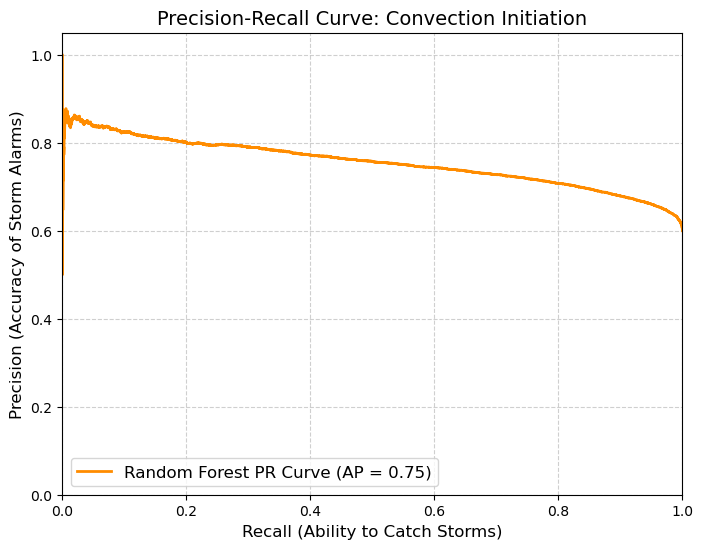

In [34]:
# 1. Extract the predicted probabilities for the positive class (Class 1: Convection On)
# [:, 1] selects the probability column corresponding to class 1
y_scores = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute Precision, Recall, and the corresponding decision thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Calculate Average Precision (AP) score to summarize the curve in a single metric
ap_score = average_precision_score(y_test, y_scores)
print(f"Average Precision Score: {ap_score:.4f}")

# 4. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'Random Forest PR Curve (AP = {ap_score:.2f})')

plt.xlabel('Recall (Ability to Catch Storms)', fontsize=12)
plt.ylabel('Precision (Accuracy of Storm Alarms)', fontsize=12)
plt.title('Precision-Recall Curve: Convection Initiation', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.show()

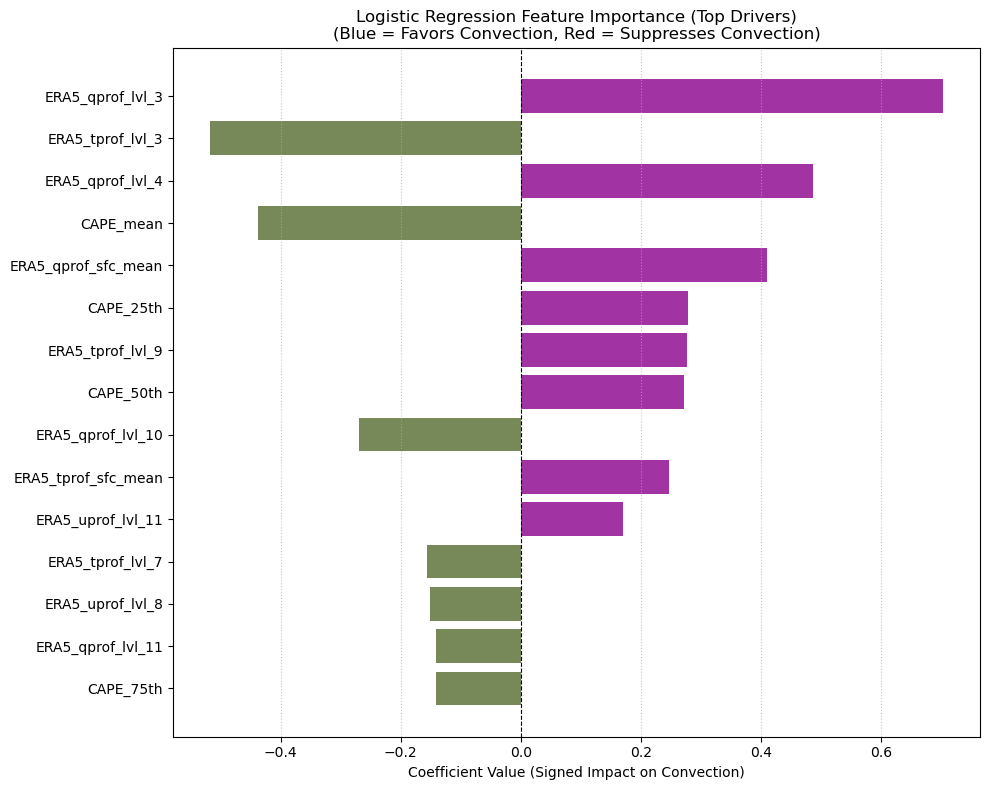

In [40]:
# 1. Extract coefficients from the trained logistic regression model
# model.coef_[0] is used for binary classification (shape: (n_features,))
coefficients = lr_model.coef_[0]
feature_names = X_train.columns

# 2. Create a DataFrame to organize and sort the features
feature_importance_df = pd.DataFrame(
    {'Feature': feature_names, 'Coefficient': coefficients}
)

# Option A: Sort by absolute magnitude to see the strongest drivers overall
feature_importance_df['Abs_Coefficient'] = np.abs(
    feature_importance_df['Coefficient']
)
feature_importance_df = feature_importance_df.sort_values(
    by='Abs_Coefficient', ascending=True
)  # Ascending for horizontal bar plot

# Optional: If you want to look at just the top N features (e.g., top 20)
# because you have many vertical levels (nlvl):
top_features = feature_importance_df.tail(15)

# 3. Plotting
plt.figure(figsize=(10, 8))

# Color bars based on positive or negative sign for physical interpretability
colors = ['darkolivegreen' if c < 0 else 'darkmagenta' for c in top_features['Coefficient']]

plt.barh(
    top_features['Feature'], top_features['Coefficient'], color=colors, alpha=0.8
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.xlabel('Coefficient Value (Signed Impact on Convection)')
plt.title(
    'Logistic Regression Feature Importance (Top Drivers)\n(Blue = Favors'
    ' Convection, Red = Suppresses Convection)'
)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### without `class_weight` = balanced